# Compare Recent Epidemiological Data

**Recent Context Notebook — 2024 vs 2025 Malaria Epidemiological Indicators**

This notebook uses `state_epidemiological_2024_2025_from_pdf.csv`.

This file is not used for long-term model training because it only covers 2024 and 2025.
Instead, it is used for recent epidemiological context:

- Which states have the highest recent burden?
- Which states increased or decreased from 2024 to 2025?
- Are Pf%, TPR, and TFR changing?
- How much of 2025 burden is imported versus indigenous?
- How do the selected project regions compare with all states/UTs?

---

## Notebook structure

| Section | Content |
|---|---|
| 1 | Setup |
| 2 | Load and clean the recent epidemiological dataset |
| 3 | Data dictionary |
| 4 | Data completeness and national totals |
| 5 | Build 2024 vs 2025 comparison table |
| 6 | Selected regions within the whole dataset |
| 7 | Highest burden states in 2025 |
| 8 | Top burden positive cases: 2024 vs 2025 |
| 9 | 2024 vs 2025 scatter comparison |
| 10 | Biggest increases/decreases in positive cases |
| 11 | Biggest increases/decreases in TPR |
| 12 | Category meanings |
| 13 | Category distribution |
| 14 | Imported vs indigenous cases |
| 15 | India-level summary |
| 16 | Interpretation notes |

## 1. Setup

In [68]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EPI_CSV = PROJECT_ROOT / "data" / "processed" / "state_epidemiological_2024_2025_from_pdf.csv"
SELECTED_REGIONS = ["Odisha", "Mizoram", "Tripura"]
HIGHLIGHT_COLORS = {"Odisha": "tab:blue", "Mizoram": "tab:orange", "Tripura": "tab:green"}

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")

def fmt_count(x, _):
    if pd.isna(x):
        return ""
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"

def color_for_state(state, default="steelblue"):
    return HIGHLIGHT_COLORS.get(state, default)

**Why this matters:** This setup cell keeps the notebook reproducible. By defining one data path, selected states, and shared formatting helpers at the start, every later table and plot uses the same assumptions and visual style.

## 2. Load and Clean the Dataset

In [69]:
epi = pd.read_csv(EPI_CSV)

numeric_cols = [
    "year",
    "tested",
    "positive",
    "pf",
    "pf_percent",
    "tpr",
    "tfr",
    "deaths",
    "imported_cases",
    "indigenous_cases",
]

for col in numeric_cols:
    epi[col] = pd.to_numeric(epi[col], errors="coerce")

epi["category"] = epi["category"].fillna("Not specified")
epi["state"] = epi["state"].str.strip()

epi_2024 = epi[epi["year"] == 2024].copy()
epi_2025 = epi[epi["year"] == 2025].copy()

display(epi.head())
display(epi.tail())
print("Shape:", epi.shape)
print("Years:", sorted(epi["year"].dropna().unique()))
print("States/UTs:", epi["state"].nunique())

,year,state,tested,positive,pf,pf_percent,tpr,tfr,deaths,imported_cases,indigenous_cases,category
0,2024,Andaman And Nicobar Islands,47413,96,46,47.92,0.202,0.10,NaN,NaN,NaN,Not specified
1,2025,Andaman And Nicobar Islands,55701,48,25,52.08,0.086,0.05,0.0,4.0,44.0,Category II
2,2024,Andhra Pradesh,12364281,7866,6201,78.83,0.064,0.05,NaN,NaN,NaN,Not specified
3,2025,Andhra Pradesh,12892737,7831,6312,80.60,0.061,0.05,8.0,287.0,7544.0,Category II
4,2024,Arunachal Pradesh,158497,19,2,10.53,0.012,0.00,NaN,NaN,NaN,Not specified


,year,state,tested,positive,pf,pf_percent,tpr,tfr,deaths,imported_cases,indigenous_cases,category
69,2025,Uttarakhand,530679,196,56,28.57,0.037,0.01,0.0,122.0,74.0,Category I
70,2024,West Bengal,13653675,21802,3841,17.62,0.160,0.03,NaN,NaN,NaN,Not specified
71,2025,West Bengal,13658022,21080,3925,18.62,0.154,0.03,0.0,0.0,21080.0,Category II
72,2024,India,181653330,255500,153472,60.07,0.141,0.08,NaN,NaN,NaN,Not specified
73,2025,India,186637835,233555,135430,57.99,0.125,0.07,55.0,4541.0,229014.0,Not specified


Shape: (74, 12)
Years: [np.int64(2024), np.int64(2025)]
States/UTs: 37


**Why this matters:** The source CSV came from a PDF extraction, so numeric fields may initially be read as text. Cleaning here prevents misleading plots, failed calculations, and incorrect change estimates later in the notebook.

## 3. Data Dictionary

In [70]:
data_dictionary = pd.DataFrame([
    {
        "variable": "year",
        "meaning": "Reporting year. This dataset contains 2024 and 2025.",
        "how_used": "Used to compare recent change between 2024 and 2025.",
    },
    {
        "variable": "state",
        "meaning": "Indian State/UT name, plus an India summary row.",
        "how_used": "Used as the regional unit for comparison.",
    },
    {
        "variable": "tested",
        "meaning": "Number of people/samples tested for malaria.",
        "how_used": "Shows surveillance/testing volume.",
    },
    {
        "variable": "positive",
        "meaning": "Total malaria positive cases.",
        "how_used": "Main raw burden indicator.",
    },
    {
        "variable": "pf",
        "meaning": "Number of Plasmodium falciparum malaria cases.",
        "how_used": "Indicates falciparum burden, often associated with more severe malaria risk.",
    },
    {
        "variable": "pf_percent",
        "meaning": "Percentage of positive malaria cases that are Pf cases.",
        "how_used": "Shows species composition of malaria burden.",
    },
    {
        "variable": "tpr",
        "meaning": "Test Positivity Rate: positive cases relative to tested population.",
        "how_used": "Shows positivity/intensity among those tested.",
    },
    {
        "variable": "tfr",
        "meaning": "Pf rate among tested population.",
        "how_used": "Shows falciparum positivity relative to testing volume.",
    },
    {
        "variable": "deaths",
        "meaning": "Reported malaria deaths.",
        "how_used": "Used as severity/outcome indicator.",
    },
    {
        "variable": "imported_cases",
        "meaning": "Cases classified as imported from outside the reporting region.",
        "how_used": "Helps distinguish introduced cases from local transmission.",
    },
    {
        "variable": "indigenous_cases",
        "meaning": "Cases classified as locally acquired within the reporting region.",
        "how_used": "Important for interpreting local transmission.",
    },
    {
        "variable": "category",
        "meaning": "Programmatic malaria category assigned in the source report.",
        "how_used": "Used for recent risk/status interpretation.",
    },
])

display(data_dictionary)

,variable,meaning,how_used
0,year,Reporting year. This dataset contains 2024 and...,Used to compare recent change between 2024 and...
1,state,"Indian State/UT name, plus an India summary row.",Used as the regional unit for comparison.
2,tested,Number of people/samples tested for malaria.,Shows surveillance/testing volume.
3,positive,Total malaria positive cases.,Main raw burden indicator.
4,pf,Number of Plasmodium falciparum malaria cases.,"Indicates falciparum burden, often associated ..."
5,pf_percent,Percentage of positive malaria cases that are ...,Shows species composition of malaria burden.
6,tpr,Test Positivity Rate: positive cases relative ...,Shows positivity/intensity among those tested.
7,tfr,Pf rate among tested population.,Shows falciparum positivity relative to testin...
8,deaths,Reported malaria deaths.,Used as severity/outcome indicator.
9,imported_cases,Cases classified as imported from outside the ...,Helps distinguish introduced cases from local ...


**Why this matters:** These epidemiological abbreviations are easy to misread. Defining them before analysis makes the notebook self-contained and helps the reader understand why each variable is useful.

## 4. Data Completeness Check

In [71]:
completeness = (
    epi
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)
completeness["missing_percent"] = completeness["missing_values"] / len(epi) * 100

display(completeness)

display(
    epi.groupby("year")
    .agg(
        rows=("state", "count"),
        total_tested=("tested", "sum"),
        total_positive=("positive", "sum"),
        total_pf=("pf", "sum"),
        total_deaths=("deaths", "sum"),
    )
    .reset_index()
)

print("\nKey check:")
print("The dataset has only 2024 and 2025, so it is best for recent comparison, not long-term model training.")

,column,missing_values,missing_percent
0,year,0,0.0
1,state,0,0.0
2,tested,0,0.0
3,positive,0,0.0
4,pf,0,0.0
5,pf_percent,0,0.0
6,tpr,0,0.0
7,tfr,0,0.0
8,deaths,37,50.0
9,imported_cases,37,50.0


,year,rows,total_tested,total_positive,total_pf,total_deaths
0,2024,37,363306660,511000,306944,0.0
1,2025,37,373275670,467110,270860,110.0



Key check:
The dataset has only 2024 and 2025, so it is best for recent comparison, not long-term model training.


**Why this matters:** Before interpreting recent changes, we need to know which columns are complete enough to trust. The yearly totals also give a first check of whether 2025 broadly increased or decreased compared with 2024.

## 5. Build a 2024 vs 2025 Comparison Table

In [72]:
value_cols = ["tested", "positive", "pf", "pf_percent", "tpr", "tfr", "deaths"]
wide = epi.pivot_table(index="state", columns="year", values=value_cols, aggfunc="first")

change_rows = []
for state in wide.index:
    row = {"state": state}
    for col in value_cols:
        v2024 = wide.get((col, 2024), pd.Series(dtype=float)).get(state, pd.NA)
        v2025 = wide.get((col, 2025), pd.Series(dtype=float)).get(state, pd.NA)
        row[f"{col}_2024"] = v2024
        row[f"{col}_2025"] = v2025
        row[f"{col}_change"] = v2025 - v2024 if pd.notna(v2024) and pd.notna(v2025) else pd.NA
        row[f"{col}_pct_change"] = (
            (v2025 - v2024) / v2024 * 100
            if pd.notna(v2024) and pd.notna(v2025) and v2024 != 0
            else pd.NA
        )
    change_rows.append(row)

changes = pd.DataFrame(change_rows)
category_2025 = epi_2025[["state", "category"]].rename(columns={"category": "category_2025"})
changes = changes.merge(category_2025, on="state", how="left")
changes_no_india = changes[changes["state"] != "India"].copy()

display(
    changes_no_india
    .sort_values("positive_2025", ascending=False)
    .head(20)[
        [
            "state",
            "positive_2024",
            "positive_2025",
            "positive_change",
            "positive_pct_change",
            "pf_percent_2024",
            "pf_percent_2025",
            "tpr_2024",
            "tpr_2025",
            "category_2025",
        ]
    ]
)

,state,positive_2024,positive_2025,positive_change,positive_pct_change,pf_percent_2024,pf_percent_2025,tpr_2024,tpr_2025,category_2025
25,Odisha,68693,62137,-6556,-9.543913,73.52,69.45,0.656,0.574,Category III
14,Jharkhand,42352,42301,-51,-0.120419,82.68,77.53,0.691,0.618,Category II
6,Chhattisgarh,31373,28836,-2537,-8.086571,87.02,87.75,0.400,0.413,Category II
20,Maharashtra,21078,23097,2019,9.578708,41.90,37.79,0.097,0.092,Category II
36,West Bengal,21802,21080,-722,-3.311623,17.62,18.62,0.160,0.154,Category II
34,Uttar Pradesh,13477,14590,1113,8.258515,7.41,4.45,0.093,0.078,Category I
23,Mizoram,16899,8865,-8034,-47.541275,52.96,57.87,5.488,3.062,Category III
1,Andhra Pradesh,7866,7831,-35,-0.444953,78.83,80.60,0.064,0.061,Category II
33,Tripura,9738,6091,-3647,-37.451222,49.30,59.78,0.821,0.713,Category III
3,Assam,5036,3969,-1067,-21.187450,22.44,12.95,0.077,0.068,Category II


**Why this matters:** Most later questions are about change. This table turns two separate yearly rows into one comparison row per state, making increases, decreases, and percentage changes easy to inspect and plot.

## 6. Selected Regions Within the Whole Dataset

In [73]:
selected_recent = changes[changes["state"].isin(SELECTED_REGIONS)].copy()
display(
    selected_recent[
        [
            "state",
            "positive_2024",
            "positive_2025",
            "positive_change",
            "pf_percent_2024",
            "pf_percent_2025",
            "tpr_2024",
            "tpr_2025",
            "deaths_2024",
            "deaths_2025",
            "category_2025",
        ]
    ].sort_values("state")
)

,state,positive_2024,positive_2025,positive_change,pf_percent_2024,pf_percent_2025,tpr_2024,tpr_2025,deaths_2024,deaths_2025,category_2025
23,Mizoram,16899,8865,-8034,52.96,57.87,5.488,3.062,<NA>,8.0,Category III
25,Odisha,68693,62137,-6556,73.52,69.45,0.656,0.574,<NA>,6.0,Category III
33,Tripura,9738,6091,-3647,49.30,59.78,0.821,0.713,<NA>,0.0,Category III


**Why this matters:** The project focuses on Odisha, Mizoram, and Tripura, but the interpretation should not ignore national context. This table keeps those regions visible while the rest of the notebook still analyzes all states/UTs.

## 7. Highest Burden States in 2025

These bar charts are more useful than two-year line plots because they show which states dominate the most recent burden.

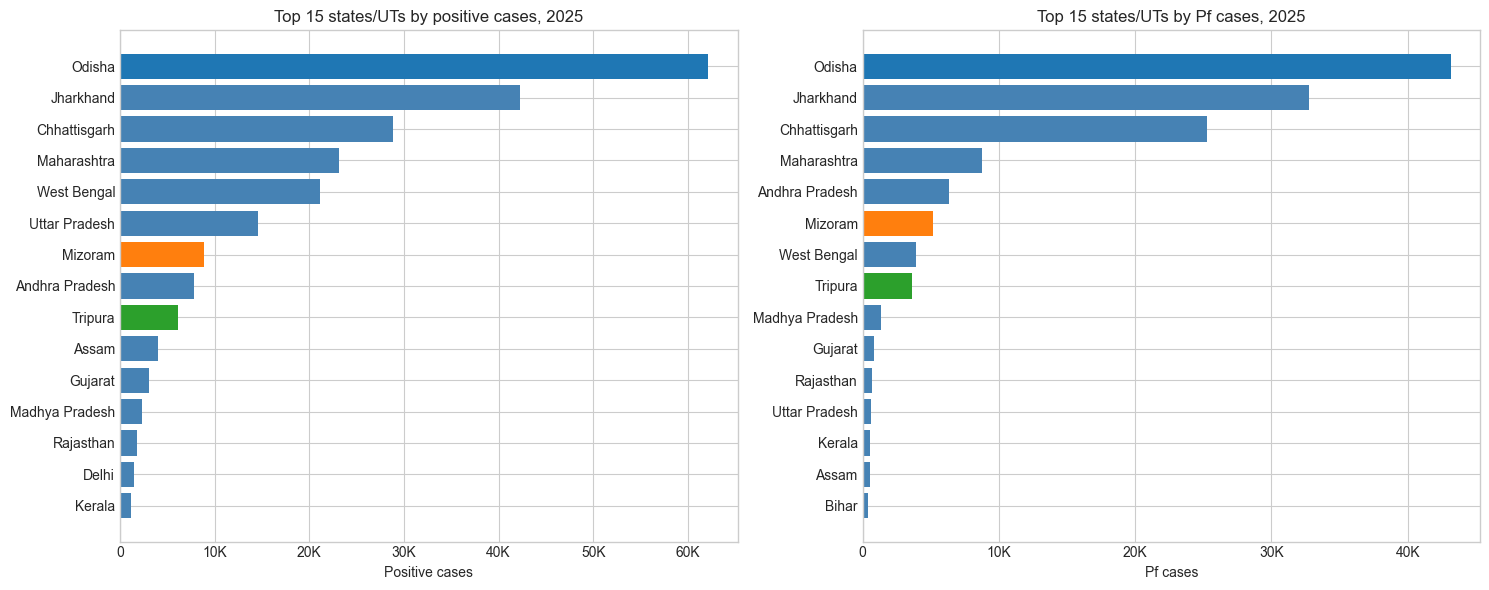

,state,tested,positive,pf,pf_percent,tpr,deaths,category
49,Odisha,10832670,62137,43153,69.45,0.574,6.0,Category III
27,Jharkhand,6844777,42301,32795,77.53,0.618,2.0,Category II
13,Chhattisgarh,6984779,28836,25304,87.75,0.413,0.0,Category II
39,Maharashtra,25221781,23097,8728,37.79,0.092,15.0,Category II
71,West Bengal,13658022,21080,3925,18.62,0.154,0.0,Category II
67,Uttar Pradesh,18697953,14590,649,4.45,0.078,0.0,Category I
45,Mizoram,289529,8865,5130,57.87,3.062,8.0,Category III
3,Andhra Pradesh,12892737,7831,6312,80.60,0.061,8.0,Category II
65,Tripura,854317,6091,3641,59.78,0.713,0.0,Category III
7,Assam,5828906,3969,514,12.95,0.068,8.0,Category II


In [74]:
top_positive = epi_2025[epi_2025["state"] != "India"].sort_values("positive", ascending=False).head(15)
top_pf = epi_2025[epi_2025["state"] != "India"].sort_values("pf", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    top_positive["state"][::-1],
    top_positive["positive"][::-1],
    color=[color_for_state(s) for s in top_positive["state"][::-1]],
)
axes[0].set_title("Top 15 states/UTs by positive cases, 2025")
axes[0].set_xlabel("Positive cases")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))

axes[1].barh(
    top_pf["state"][::-1],
    top_pf["pf"][::-1],
    color=[color_for_state(s) for s in top_pf["state"][::-1]],
)
axes[1].set_title("Top 15 states/UTs by Pf cases, 2025")
axes[1].set_xlabel("Pf cases")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))

plt.tight_layout()
plt.show()

display(top_positive[["state", "tested", "positive", "pf", "pf_percent", "tpr", "deaths", "category"]])

**Why this matters:** Ranking states by 2025 burden answers a practical public-health question: where are the largest current case loads? It also shows whether the selected regions are nationally prominent in raw burden.

## 8. Top Burden Positive Cases: 2024 vs 2025

This grouped bar chart compares 2024 and 2025 positive cases for the states/UTs with the highest recent burden.

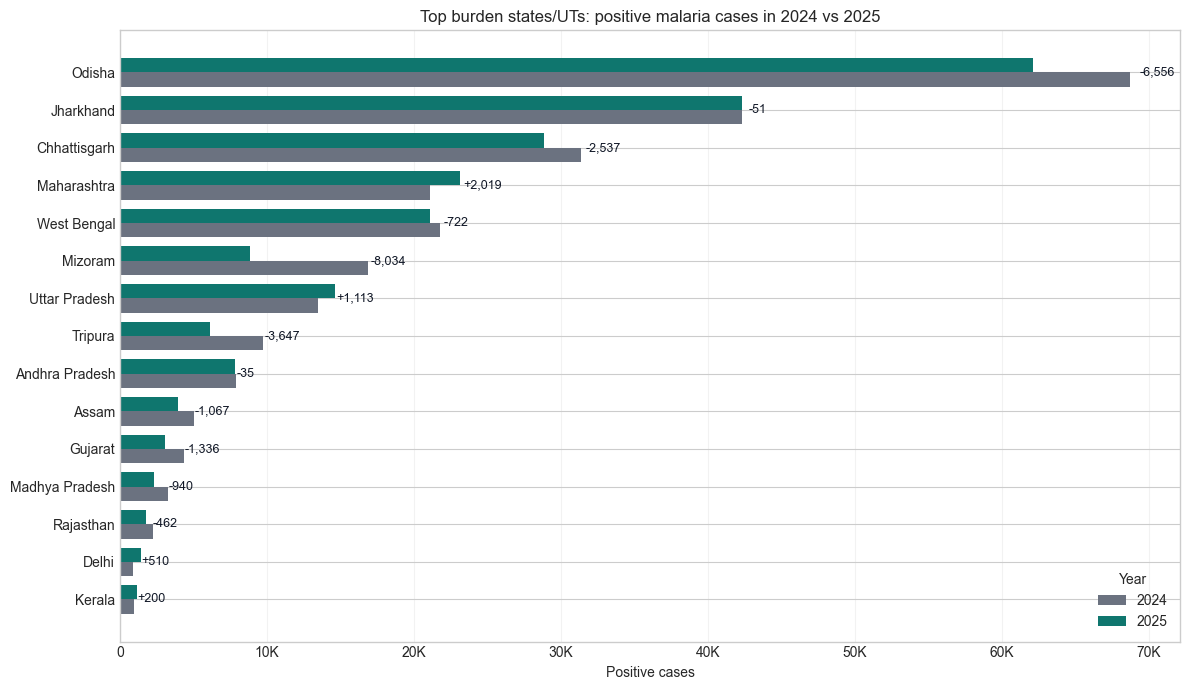

,state,positive_2024,positive_2025,positive_change,positive_pct_change,tpr_2024,tpr_2025,category_2025
25,Odisha,68693,62137,-6556,-9.543913,0.656,0.574,Category III
14,Jharkhand,42352,42301,-51,-0.120419,0.691,0.618,Category II
6,Chhattisgarh,31373,28836,-2537,-8.086571,0.400,0.413,Category II
20,Maharashtra,21078,23097,2019,9.578708,0.097,0.092,Category II
36,West Bengal,21802,21080,-722,-3.311623,0.160,0.154,Category II
34,Uttar Pradesh,13477,14590,1113,8.258515,0.093,0.078,Category I
23,Mizoram,16899,8865,-8034,-47.541275,5.488,3.062,Category III
1,Andhra Pradesh,7866,7831,-35,-0.444953,0.064,0.061,Category II
33,Tripura,9738,6091,-3647,-37.451222,0.821,0.713,Category III
3,Assam,5036,3969,-1067,-21.187450,0.077,0.068,Category II


In [75]:
top_burden_compare = (
    changes_no_india
    .assign(max_recent_positive=lambda df: df[["positive_2024", "positive_2025"]].max(axis=1))
    .sort_values("max_recent_positive", ascending=False)
    .head(15)
    .sort_values("max_recent_positive", ascending=True)
)

y_pos = np.arange(len(top_burden_compare))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    y_pos - bar_height / 2,
    top_burden_compare["positive_2024"],
    height=bar_height,
    label="2024",
    color="#6b7280",
)
ax.barh(
    y_pos + bar_height / 2,
    top_burden_compare["positive_2025"],
    height=bar_height,
    label="2025",
    color="#0f766e",
)

for idx, (_, row) in enumerate(top_burden_compare.iterrows()):
    change = row["positive_change"]
    change_label = f"{change:+,.0f}"
    x_position = max(row["positive_2024"], row["positive_2025"])
    ax.text(
        x_position * 1.01,
        idx,
        change_label,
        va="center",
        fontsize=9,
        color="#111827",
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(top_burden_compare["state"])
ax.set_title("Top burden states/UTs: positive malaria cases in 2024 vs 2025")
ax.set_xlabel("Positive cases")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))
ax.legend(title="Year")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

display(
    top_burden_compare[
        [
            "state",
            "positive_2024",
            "positive_2025",
            "positive_change",
            "positive_pct_change",
            "tpr_2024",
            "tpr_2025",
            "category_2025",
        ]
    ].sort_values("positive_2025", ascending=False)
)

**Why this matters:** This graph directly compares the same high-burden states across both recent years. The side-by-side bars show whether burden increased or decreased, while the change labels make the direction and size of change easy to explain in a presentation.

## 9. 2024 vs 2025 Scatter Comparison for All States/UTs

Each point is one state/UT. Points above the diagonal increased in 2025; points below the diagonal decreased.

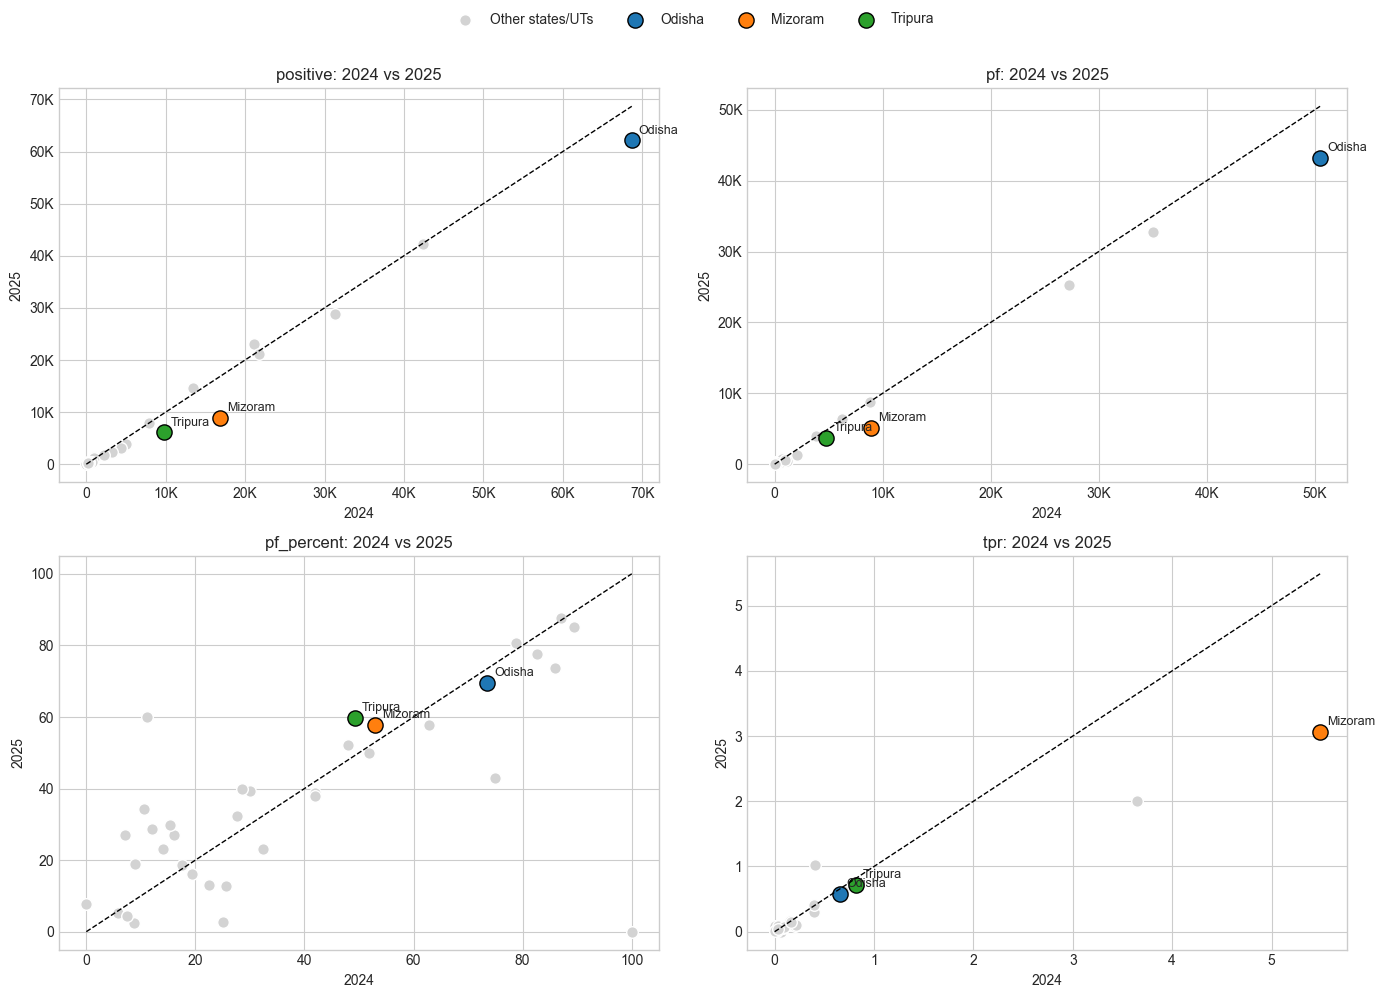

Reading guide:
  Above the diagonal = value increased in 2025.
  Below the diagonal = value decreased in 2025.


In [76]:
scatter_metrics = ["positive", "pf", "pf_percent", "tpr"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, scatter_metrics):
    x = changes_no_india[f"{metric}_2024"]
    y = changes_no_india[f"{metric}_2025"]
    max_value = max(x.max(skipna=True), y.max(skipna=True))

    ax.scatter(x, y, color="lightgray", edgecolor="white", s=70, label="Other states/UTs")

    for state in SELECTED_REGIONS:
        row = changes_no_india[changes_no_india["state"] == state]
        if not row.empty:
            ax.scatter(
                row[f"{metric}_2024"],
                row[f"{metric}_2025"],
                color=HIGHLIGHT_COLORS[state],
                edgecolor="black",
                s=120,
                label=state,
            )
            ax.annotate(
                state,
                (row[f"{metric}_2024"].iloc[0], row[f"{metric}_2025"].iloc[0]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=9,
            )

    ax.plot([0, max_value], [0, max_value], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"{metric}: 2024 vs 2025")
    ax.set_xlabel("2024")
    ax.set_ylabel("2025")
    if metric in {"positive", "pf"}:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Reading guide:")
print("  Above the diagonal = value increased in 2025.")
print("  Below the diagonal = value decreased in 2025.")

**Why this matters:** A 2024-vs-2025 scatter plot is better than a two-point line plot for many states. The diagonal line instantly shows which states increased, decreased, or stayed similar.

## 10. Biggest Increases and Decreases in Positive Cases

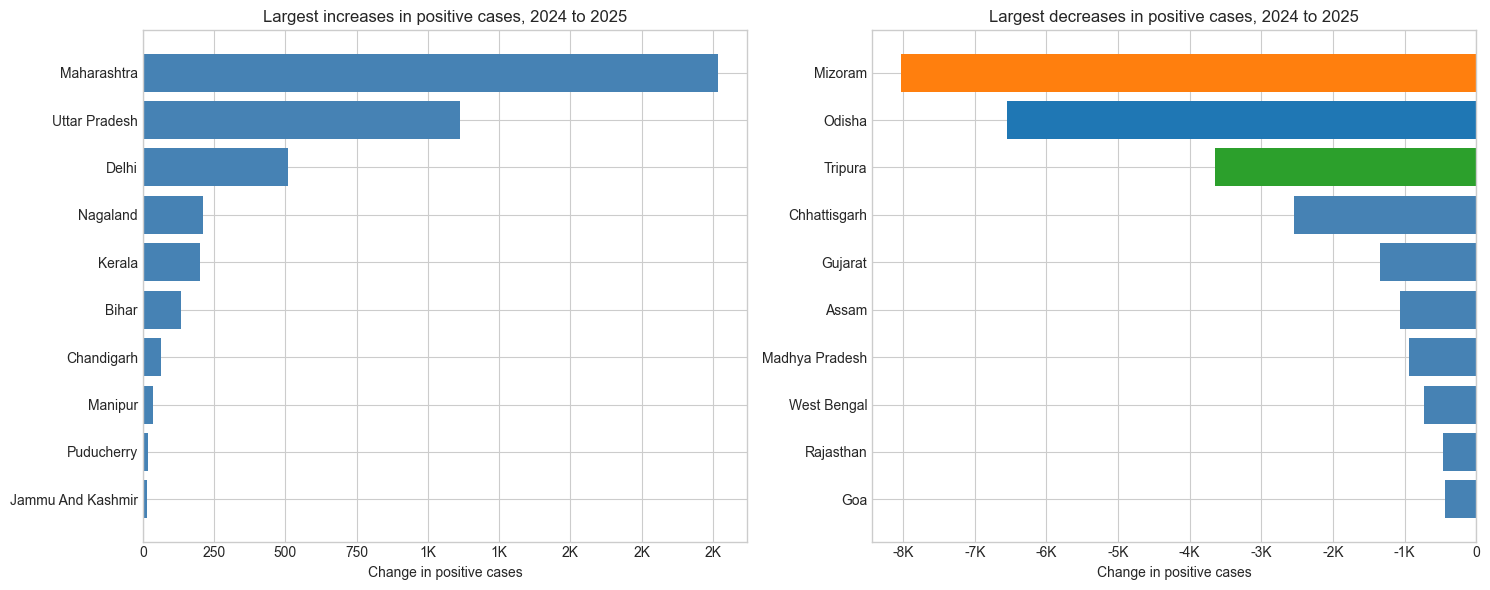

Largest increases:


,state,positive_2024,positive_2025,positive_change,positive_pct_change
20,Maharashtra,21078,23097,2019,9.578708
34,Uttar Pradesh,13477,14590,1113,8.258515
7,Delhi,910,1420,510,56.043956
24,Nagaland,12,224,212,1766.666667
16,Kerala,954,1154,200,20.964361
4,Bihar,906,1041,135,14.900662
5,Chandigarh,2,65,63,3150.000000
21,Manipur,43,79,36,83.720930
26,Puducherry,4,21,17,425.000000
13,Jammu And Kashmir,108,124,16,14.814815


Largest decreases:


,state,positive_2024,positive_2025,positive_change,positive_pct_change
23,Mizoram,16899,8865,-8034,-47.541275
25,Odisha,68693,62137,-6556,-9.543913
33,Tripura,9738,6091,-3647,-37.451222
6,Chhattisgarh,31373,28836,-2537,-8.086571
9,Gujarat,4365,3029,-1336,-30.607102
3,Assam,5036,3969,-1067,-21.187450
19,Madhya Pradesh,3247,2307,-940,-28.949800
36,West Bengal,21802,21080,-722,-3.311623
28,Rajasthan,2213,1751,-462,-20.876638
8,Goa,884,448,-436,-49.321267


In [77]:
top_increase = changes_no_india.sort_values("positive_change", ascending=False).head(10)
top_decrease = changes_no_india.sort_values("positive_change", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    top_increase["state"][::-1],
    top_increase["positive_change"][::-1],
    color=[color_for_state(s) for s in top_increase["state"][::-1]],
)
axes[0].set_title("Largest increases in positive cases, 2024 to 2025")
axes[0].set_xlabel("Change in positive cases")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))

axes[1].barh(
    top_decrease["state"][::-1],
    top_decrease["positive_change"][::-1],
    color=[color_for_state(s) for s in top_decrease["state"][::-1]],
)
axes[1].set_title("Largest decreases in positive cases, 2024 to 2025")
axes[1].set_xlabel("Change in positive cases")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))

plt.tight_layout()
plt.show()

print("Largest increases:")
display(top_increase[["state", "positive_2024", "positive_2025", "positive_change", "positive_pct_change"]])
print("Largest decreases:")
display(top_decrease[["state", "positive_2024", "positive_2025", "positive_change", "positive_pct_change"]])

**Why this matters:** Absolute change highlights where the largest operational shifts occurred. This is useful for recent programme monitoring because it names the states that need attention due to rising or falling case counts.

## 11. Biggest Increases and Decreases in TPR

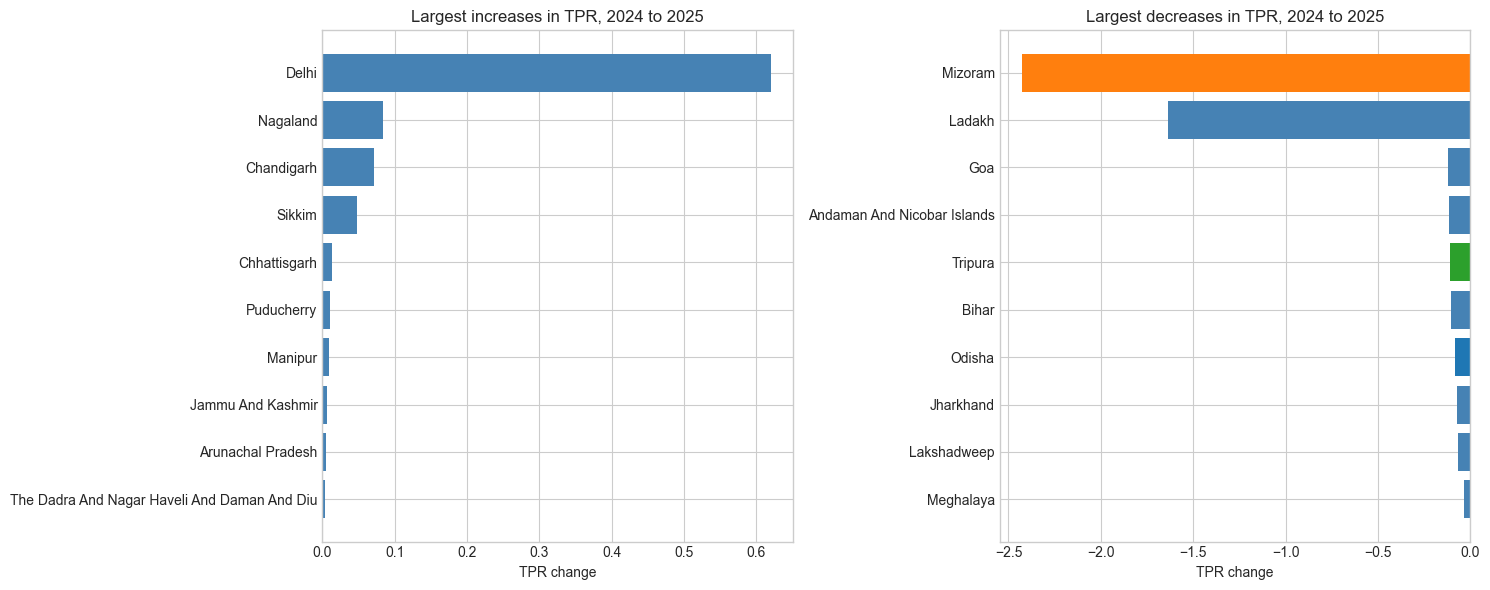

Largest TPR increases:


,state,tpr_2024,tpr_2025,tpr_change
7,Delhi,0.406,1.026,0.620
24,Nagaland,0.004,0.088,0.084
5,Chandigarh,0.003,0.075,0.072
29,Sikkim,0.032,0.080,0.048
6,Chhattisgarh,0.400,0.413,0.013
26,Puducherry,0.002,0.013,0.011
21,Manipur,0.029,0.038,0.009
13,Jammu And Kashmir,0.023,0.029,0.006
2,Arunachal Pradesh,0.012,0.017,0.005
32,The Dadra And Nagar Haveli And Daman And Diu,0.159,0.163,0.004


Largest TPR decreases:


,state,tpr_2024,tpr_2025,tpr_change
23,Mizoram,5.488,3.062,-2.426
17,Ladakh,3.644,2.008,-1.636
8,Goa,0.217,0.098,-0.119
0,Andaman And Nicobar Islands,0.202,0.086,-0.116
33,Tripura,0.821,0.713,-0.108
4,Bihar,0.401,0.297,-0.104
25,Odisha,0.656,0.574,-0.082
14,Jharkhand,0.691,0.618,-0.073
18,Lakshadweep,0.069,0.000,-0.069
22,Meghalaya,0.085,0.050,-0.035


In [78]:
tpr_data = changes_no_india.dropna(subset=["tpr_change"]).copy()
top_tpr_increase = tpr_data.sort_values("tpr_change", ascending=False).head(10)
top_tpr_decrease = tpr_data.sort_values("tpr_change", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    top_tpr_increase["state"][::-1],
    top_tpr_increase["tpr_change"][::-1],
    color=[color_for_state(s) for s in top_tpr_increase["state"][::-1]],
)
axes[0].set_title("Largest increases in TPR, 2024 to 2025")
axes[0].set_xlabel("TPR change")

axes[1].barh(
    top_tpr_decrease["state"][::-1],
    top_tpr_decrease["tpr_change"][::-1],
    color=[color_for_state(s) for s in top_tpr_decrease["state"][::-1]],
)
axes[1].set_title("Largest decreases in TPR, 2024 to 2025")
axes[1].set_xlabel("TPR change")

plt.tight_layout()
plt.show()

print("Largest TPR increases:")
display(top_tpr_increase[["state", "tpr_2024", "tpr_2025", "tpr_change"]])
print("Largest TPR decreases:")
display(top_tpr_decrease[["state", "tpr_2024", "tpr_2025", "tpr_change"]])

**Why this matters:** Raw case counts can be affected by population size and testing volume. TPR helps reveal whether positivity among tested people changed, which is closer to epidemic intensity.

## 12. Category Meaning

In [79]:
category_meaning = pd.DataFrame([
    {
        "category": "Category 0",
        "meaning": "Transmission interrupted / zero indigenous malaria cases.",
        "interpretation": "Lowest programme-risk group; focus is on preventing reintroduction.",
    },
    {
        "category": "Category I",
        "meaning": "Annual Parasite Incidence (API) is below 1 in all districts.",
        "interpretation": "Low malaria intensity across districts.",
    },
    {
        "category": "Category II",
        "meaning": "State/UT API is below 1 overall, but at least one district has API above 1.",
        "interpretation": "State looks low overall, but district-level hotspots remain important.",
    },
    {
        "category": "Category III",
        "meaning": "State/UT API is above 1.",
        "interpretation": "Higher malaria intensity; stronger surveillance and control attention is needed.",
    },
])

display(category_meaning)

,category,meaning,interpretation
0,Category 0,Transmission interrupted / zero indigenous mal...,Lowest programme-risk group; focus is on preve...
1,Category I,Annual Parasite Incidence (API) is below 1 in ...,Low malaria intensity across districts.
2,Category II,"State/UT API is below 1 overall, but at least ...","State looks low overall, but district-level ho..."
3,Category III,State/UT API is above 1.,Higher malaria intensity; stronger surveillanc...


**Why this matters:** The category labels are not just names. They are programme-risk groups based on malaria intensity, especially API. This table makes the next category chart interpretable: Category III states are generally higher-risk than Category I states.

## 13. Category Distribution in 2025

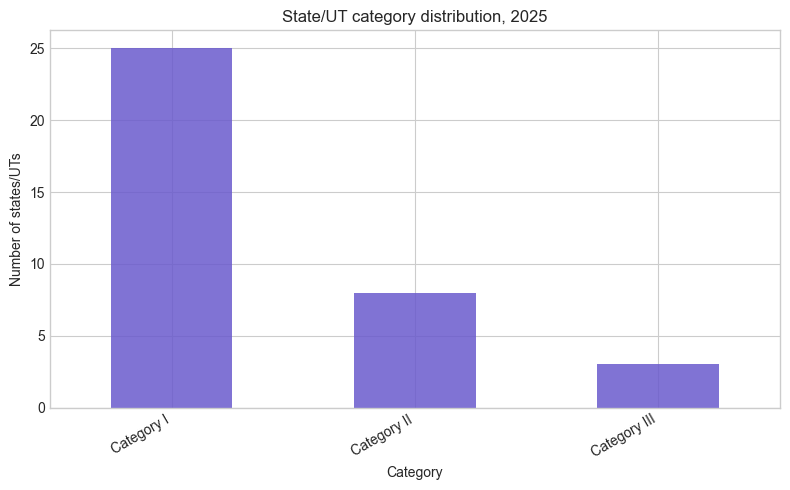

,category,state_count
0,Category I,25
1,Category II,8
2,Category III,3


In [80]:
category_counts = (
    epi_2025[epi_2025["state"] != "India"]
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
category_counts.plot(kind="bar", ax=ax, color="slateblue", alpha=0.85)
ax.set_title("State/UT category distribution, 2025")
ax.set_xlabel("Category")
ax.set_ylabel("Number of states/UTs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(category_counts.reset_index(name="state_count"))

**Why this matters:** Categories summarize recent programme status in a simple way. Counting categories gives a compact national overview that can be cited in the discussion section.

## 14. Imported vs Indigenous Cases in 2025

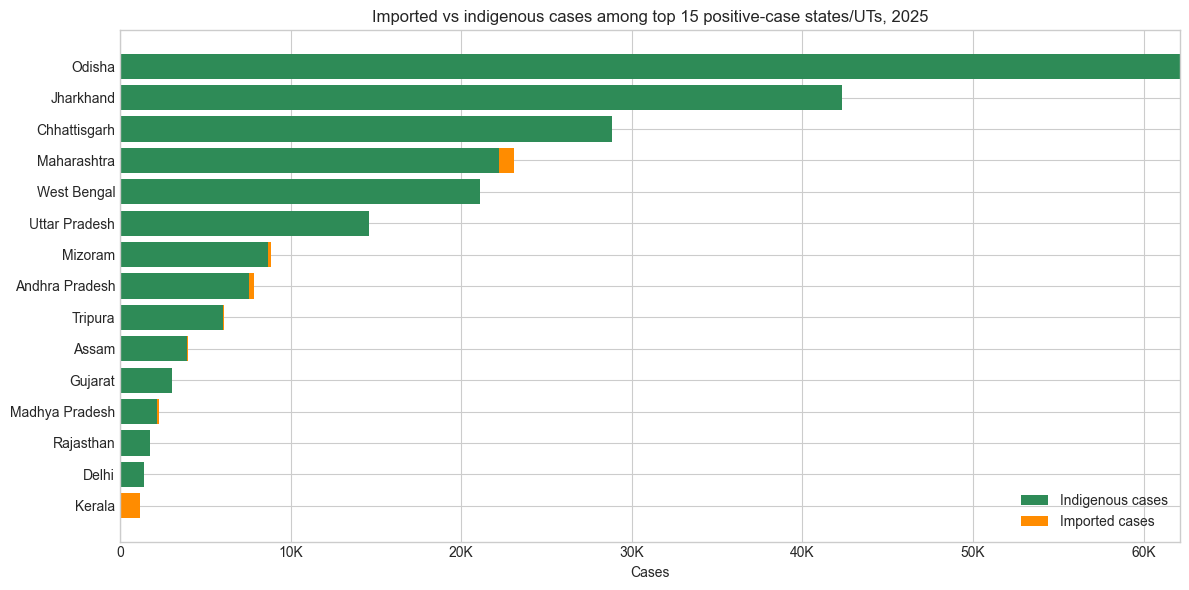

,state,positive,imported_cases,indigenous_cases,category,imported_share,indigenous_share
49,Odisha,62137,0.0,62137.0,Category III,0.000000,1.000000
27,Jharkhand,42301,0.0,42301.0,Category II,0.000000,1.000000
13,Chhattisgarh,28836,0.0,28836.0,Category II,0.000000,1.000000
39,Maharashtra,23097,891.0,22206.0,Category II,0.038576,0.961424
71,West Bengal,21080,0.0,21080.0,Category II,0.000000,1.000000
67,Uttar Pradesh,14590,0.0,14590.0,Category I,0.000000,1.000000
45,Mizoram,8865,184.0,8681.0,Category III,0.020756,0.979244
3,Andhra Pradesh,7831,287.0,7544.0,Category II,0.036649,0.963351
65,Tripura,6091,58.0,6033.0,Category III,0.009522,0.990478
7,Assam,3969,39.0,3930.0,Category II,0.009826,0.990174


In [81]:
imported_view = epi_2025[epi_2025["state"] != "India"][
    ["state", "positive", "imported_cases", "indigenous_cases", "category"]
].copy()

imported_view["imported_cases"] = imported_view["imported_cases"].fillna(0)
imported_view["indigenous_cases"] = imported_view["indigenous_cases"].fillna(0)
imported_view["imported_share"] = imported_view["imported_cases"] / imported_view["positive"]
imported_view["indigenous_share"] = imported_view["indigenous_cases"] / imported_view["positive"]

top_imported = imported_view.sort_values("positive", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_imported["state"][::-1], top_imported["indigenous_cases"][::-1], label="Indigenous cases", color="seagreen")
ax.barh(
    top_imported["state"][::-1],
    top_imported["imported_cases"][::-1],
    left=top_imported["indigenous_cases"][::-1],
    label="Imported cases",
    color="darkorange",
)
ax.set_title("Imported vs indigenous cases among top 15 positive-case states/UTs, 2025")
ax.set_xlabel("Cases")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))
ax.legend()
plt.tight_layout()
plt.show()

display(imported_view.sort_values("positive", ascending=False).head(20))

**Why this matters:** Imported cases and indigenous cases have different policy meanings. Indigenous cases suggest local transmission, while imported cases may reflect movement from other areas.

## 15. National Summary: India Row

,year,state,tested,positive,pf,pf_percent,tpr,tfr,deaths,imported_cases,indigenous_cases,category
72,2024,India,181653330,255500,153472,60.07,0.141,0.08,NaN,NaN,NaN,Not specified
73,2025,India,186637835,233555,135430,57.99,0.125,0.07,55.0,4541.0,229014.0,Not specified


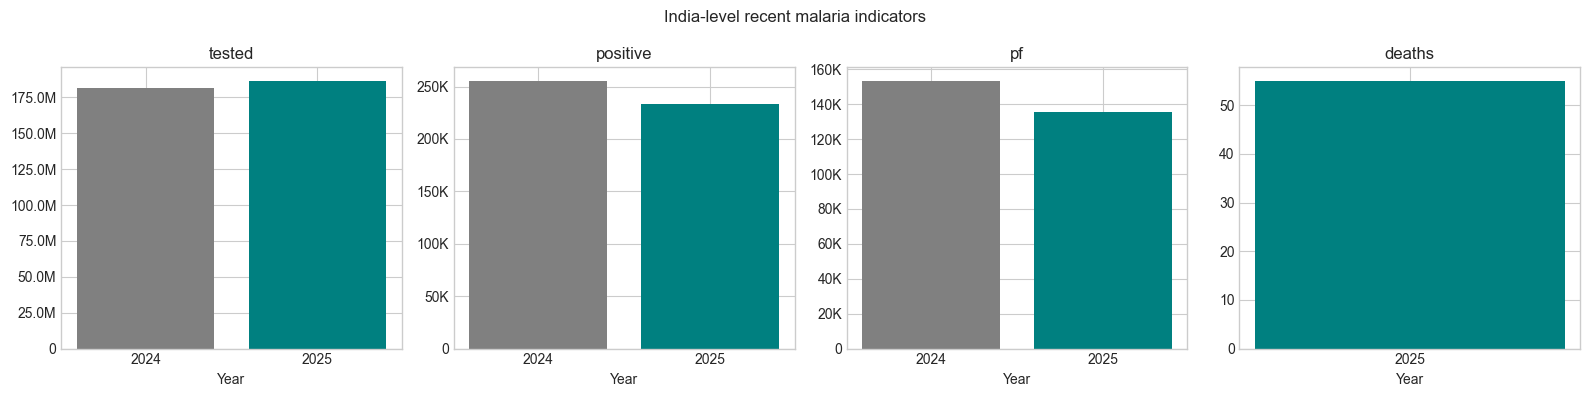

In [82]:
india_recent = epi[epi["state"] == "India"].sort_values("year")
display(india_recent)

national_metrics = ["tested", "positive", "pf", "deaths"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, metric in zip(axes, national_metrics):
    ax.bar(india_recent["year"].astype(str), india_recent[metric], color=["gray", "teal"])
    ax.set_title(metric)
    ax.set_xlabel("Year")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_count))

plt.suptitle("India-level recent malaria indicators")
plt.tight_layout()
plt.show()

**Why this matters:** State-level heterogeneity is important, but the India row provides the national backdrop. It helps explain whether selected-state changes are part of a broader national pattern or local exceptions.

## 16. Interpretation Notes

Use this section in the final report:

- The recent 2024-2025 file adds epidemiological context to the long-term modelling dataset.
- It should not be used alone for time-series or AI/ML training because it has only two years.
- It is useful for explaining recent state status, category, positivity, Pf burden, and imported versus indigenous cases.
- The category meaning table explains why Category III represents a higher programme-risk group than Category I.
- The best whole-dataset plots are rankings, grouped 2024-vs-2025 burden comparisons, scatter comparisons, and increase/decrease bars rather than dense two-year line plots.
- For Odisha, Mizoram, and Tripura, compare whether the latest indicators agree with the long-term risk patterns.